In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
from pathlib import Path

In [2]:
# submission folder
main_folder = Path("Baliti_Ocean Modelling Exercises")
figures_folder = main_folder / "Figures"

figures_folder.mkdir(parents=True, exist_ok=True)

In [3]:
# Load data
df = pd.read_csv('flynn94.csv')
df.head()

,time,cells,biovolume,ammonium,cellC,chl-a
0,0.0,0.04,2.0,1.411,0.60,4.0
1,0.5,0.04,2.2,1.400,0.61,3.0
2,1.0,0.04,2.1,1.383,0.58,3.0
3,1.5,0.04,2.1,1.355,NaN,3.0
4,2.0,0.04,2.1,1.355,0.68,3.0


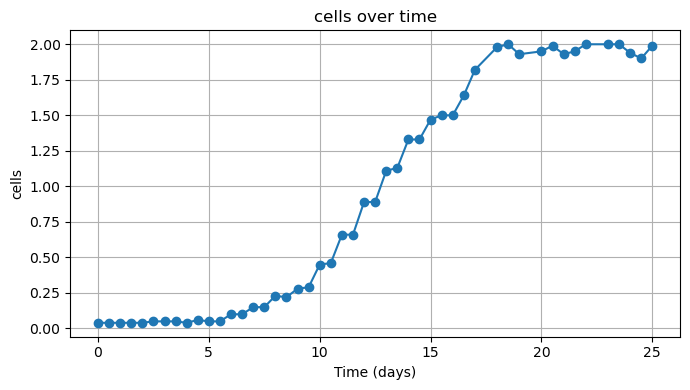

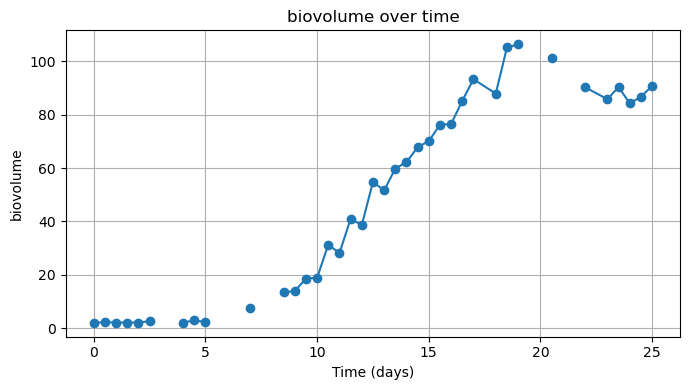

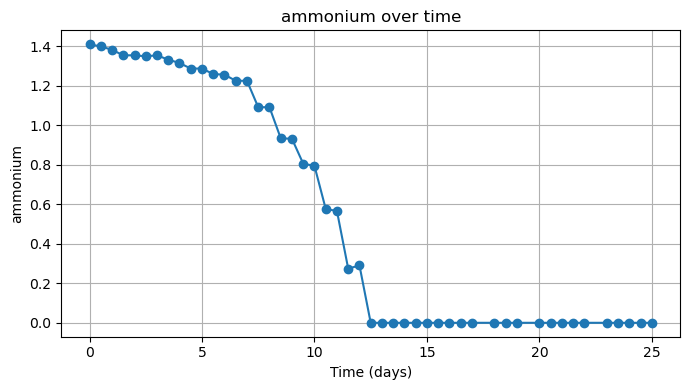

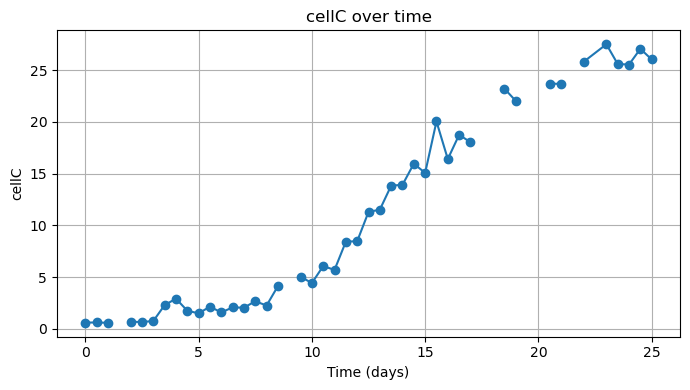

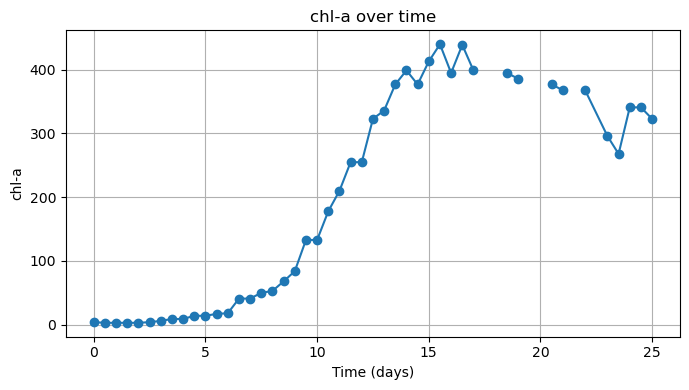

In [4]:
# Plot all variables as time series
variables = ['cells', 'biovolume', 'ammonium', 'cellC', 'chl-a']

for var in variables:
    plt.figure(figsize=(7, 4))
    plt.plot(df['time'], df[var], marker='o')
    plt.xlabel('Time (days)')
    plt.ylabel(var)
    plt.title(f'{var} over time')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(figures_folder / f'ex1_{var}_timeseries.png', dpi=200)
    plt.show()

In [5]:
def fit_exponential(data, var, tmin=6, tmax=15.5):
    sub = data[['time', var]].dropna()
    sub = sub[(sub['time'] >= tmin) & (sub['time'] <= tmax) & (sub[var] > 0)]
    fit = linregress(sub['time'], np.log(sub[var]))
    mu = fit.slope
    doubling_time = np.log(2) / mu if mu > 0 else np.nan
    r2 = fit.rvalue**2
    return {'variable': var, 'tmin': tmin, 'tmax': tmax, 'mu_per_day': mu, 'doubling_days': doubling_time, 'r2': r2, 'n': len(sub)}

results = pd.DataFrame([fit_exponential(df, var) for var in ['cells', 'cellC', 'chl-a', 'biovolume']])
results

,variable,tmin,tmax,mu_per_day,doubling_days,r2,n
0,cells,6,15.5,0.309082,2.242598,0.971197,20
1,cellC,6,15.5,0.264147,2.624100,0.974778,19
2,chl-a,6,15.5,0.317354,2.184147,0.934555,20
3,biovolume,6,15.5,0.276485,2.506994,0.948696,16


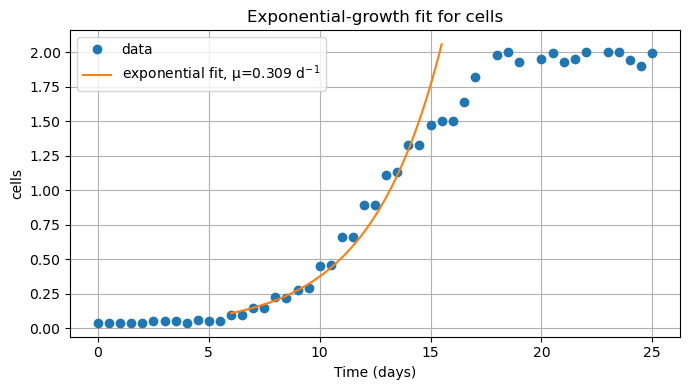

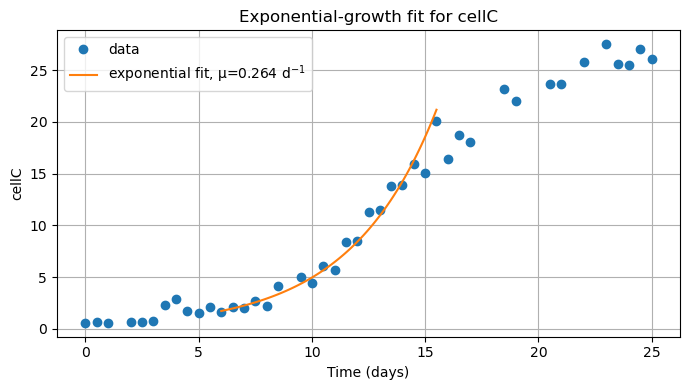

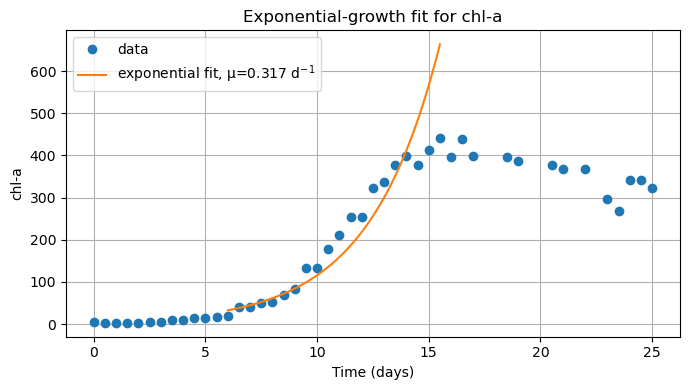

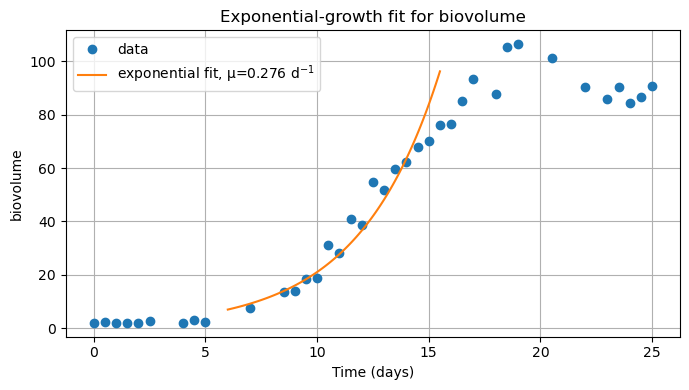

In [6]:
# Plot exponential fits for the growth phase
tmin, tmax = 6, 15.5
for var in ['cells', 'cellC', 'chl-a', 'biovolume']:
    sub = df[['time', var]].dropna()
    sub = sub[(sub['time'] >= tmin) & (sub['time'] <= tmax) & (sub[var] > 0)]
    fit = linregress(sub['time'], np.log(sub[var]))
    t_fit = np.linspace(tmin, tmax, 100)
    y_fit = np.exp(fit.intercept + fit.slope*t_fit)

    plt.figure(figsize=(7, 4))
    plt.plot(df['time'], df[var], 'o', label='data')
    plt.plot(t_fit, y_fit, label=f'exponential fit, μ={fit.slope:.3f} d$^{{-1}}$')
    plt.xlabel('Time (days)')
    plt.ylabel(var)
    plt.title(f'Exponential-growth fit for {var}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(figures_folder / f'ex1_{var}_Exponential Fit_timeseries.png', dpi=200)
    plt.show()

## Answers

1. The growth is not exponential throughout the whole experiment. From the cell number plot, the cells stay low at the beginning, then start increasing quickly around day 8. The exponential growth seems to be between about day 8 and day 16, because this is where the curve rises fastest. After about day 18, the cell number becomes almost constant, so growth has slowed down
   
2. Yes, the curve can be separated into phases. From day 0 to about day 7, there is a lag phase. From about day 8 to day 16, there is a rapid growth phase. After about day 18, there is a stationary phase.

3. The three of them show growth, but they seem to grow differently. Cell number increases rapidly and then becomes stationary. Cellular carbon keeps growing but more gradually and doesn't seem to reach stationary point. Chlorophyll-a increases strongly during the growth phase, but then decreases after its peak.

4. No, ammonium consumption is not approximated by a single exponential curve.

5. I fitted the exponential curve from day 6 to day 15.5 because that is the part that seems exponential, the slope gives the growth rate.



AI prompt:

Question 5

"I am working with this phytoplankton growth data and I want to estimate the growth rate during the exponential phase. Please help me write a code (jupyter lab) that fits an exponential curve to the variables in the data. Use the period from day 6 to day 15.5.Tthen I want the code to take the natural log of each variable and fit a straight line against time. Also plot the original data with the fitted exponential curve on top for each variable so I can check if the fit makes sense."